In [231]:
#%pip install flowkit

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['savefig.dpi'] = 600
import seaborn as sns
import json
from matplotlib.patches import Rectangle
from matplotlib import cm
import flowkit as fk
from bokeh.plotting import show
import bokeh
bokeh.io.output_notebook()

Loading BokehJS ...

In [233]:
fk.__version__

'1.2.3'

# First for FACS (sort-seq) experiments

## Importing the FACS data

In [236]:
sample_1 = fk.Sample("FACS_sorting_data/fcy1_promDMS_sorting_rep1_20250128.fcs")
df_1 =  sample_1.as_dataframe(source='raw')
df_1

pnn,Time,FSC-A,FSC-H,FSC-W,YellowGreen_D-A,YellowGreen_D-H,YellowGreen_D-W,YellowGreen_C-A,YellowGreen_C-H,YellowGreen_C-W,...,*YellowGreen_B-H,*YellowGreen_A-A,*YellowGreen_A-H,*sfGFP*-A,*sfGFP*-H,*PerCP-Cy5.5-A,*PerCP-Cy5.5-H,IndexSort,DeltaTime,SortMembershipMap
pns,,FSC-A,FSC-H,FSC-W,YellowGreen_D-A,YellowGreen_D-H,YellowGreen_D-W,YellowGreen_C-A,YellowGreen_C-H,YellowGreen_C-W,...,*YellowGreen_B-H,*YellowGreen_A-A,*YellowGreen_A-H,*sfGFP*-A,*sfGFP*-H,*PerCP-Cy5.5-A,*PerCP-Cy5.5-H,,,
0,1472.85,48611.492188,39160.0,81353.492188,74.410439,49.0,99521.679688,26.914413,85.0,20751.330078,...,99.0,7.124403,43.0,19560.162109,16516.0,1056.358032,1188.0,3.531272e-43,110.0,3.531272e-43
1,1472.86,52488.949219,44457.0,77376.242188,34.830418,52.0,43897.042969,44.329624,80.0,36314.828125,...,54.0,-3.958002,58.0,12723.515625,10212.0,540.995667,768.0,3.545285e-43,10156.0,3.545285e-43
2,1472.86,58330.378906,44572.0,85765.492188,14.248807,33.0,28297.267578,30.080816,49.0,40232.167969,...,109.0,-8.707604,64.0,10471.840820,9659.0,680.629211,790.0,3.559298e-43,1753.0,3.559298e-43
3,1472.87,36217.128906,31508.0,75330.890625,36.413620,16.0,149150.171875,-0.791600,56.0,0.000000,...,62.0,-26.914413,19.0,4959.351562,4771.0,193.598190,243.0,3.573311e-43,3831.0,3.573311e-43
4,1472.87,28291.669922,27133.0,68334.609375,22.164812,48.0,30262.355469,39.580021,48.0,54039.921875,...,70.0,24.539612,74.0,7265.666016,7354.0,140.308105,506.0,3.138909e-43,572.0,3.138909e-43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1602.08,36234.183594,31657.0,75011.640625,14.248807,61.0,15308.357422,14.248807,48.0,19454.371094,...,79.0,7.916004,34.0,8085.928711,7174.0,365.610535,478.0,3.573311e-43,39361.0,3.573311e-43
19996,1602.08,42278.218750,33317.0,83163.117188,39.580021,73.0,35533.101562,10.290805,73.0,9238.605469,...,75.0,0.791600,70.0,6877.120605,5592.0,330.533508,344.0,3.138909e-43,3653.0,3.138909e-43
19997,1602.09,46760.082031,38963.0,78650.742188,49.079224,71.0,45302.199219,53.828827,127.0,27777.369141,...,111.0,-5.541203,34.0,11032.398438,9340.0,73.526840,380.0,3.152922e-43,9244.0,3.152922e-43


In [237]:
sample_2 = fk.Sample("FACS_sorting_data/fcy1_promDMS_sorting_rep2_20250129.fcs")
df_2 =  sample_2.as_dataframe(source='raw')
df_2

pnn,Time,FSC-A,FSC-H,FSC-W,YellowGreen_D-A,YellowGreen_D-H,YellowGreen_D-W,YellowGreen_C-A,YellowGreen_C-H,YellowGreen_C-W,...,*YellowGreen_B-H,*YellowGreen_A-A,*YellowGreen_A-H,*sfGFP*-A,*sfGFP*-H,*PerCP-Cy5.5-A,*PerCP-Cy5.5-H,IndexSort,DeltaTime,SortMembershipMap
pns,,FSC-A,FSC-H,FSC-W,YellowGreen_D-A,YellowGreen_D-H,YellowGreen_D-W,YellowGreen_C-A,YellowGreen_C-H,YellowGreen_C-W,...,*YellowGreen_B-H,*YellowGreen_A-A,*YellowGreen_A-H,*sfGFP*-A,*sfGFP*-H,*PerCP-Cy5.5-A,*PerCP-Cy5.5-H,,,
0,284.15,28835.029297,22630.0,83505.640625,2.366984,62.0,2501.978516,8.678942,90.0,6319.812500,...,71.0,-9.467937,63.0,6993.894531,5614.0,322.461639,526.0,3.265025e-43,841.0,3.265025e-43
1,284.15,53304.847656,38593.0,90518.656250,224.863495,229.0,64352.207031,344.001709,397.0,56787.140625,...,358.0,110.459259,142.0,6594.882324,4666.0,1190.262817,1207.0,3.279038e-43,633.0,3.279038e-43
2,284.15,28776.873047,24177.0,78004.765625,11.834921,37.0,20962.523438,10.256931,61.0,11019.644531,...,59.0,39.449738,70.0,3848.538818,4282.0,361.753174,615.0,3.293051e-43,2085.0,3.293051e-43
3,284.15,17994.525391,16954.0,69558.179688,-9.467937,35.0,0.000000,21.302858,71.0,19663.437500,...,82.0,15.779895,38.0,4217.744141,3994.0,-14.903688,307.0,3.307064e-43,734.0,3.307064e-43
4,284.16,16161.546875,15748.0,67256.992188,39.449738,60.0,43089.628906,35.504765,40.0,58171.007812,...,94.0,12.623916,71.0,1757.280396,1782.0,88.744690,262.0,3.321077e-43,4166.0,3.321077e-43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,362.92,11032.765625,10978.0,65862.937500,-1.577989,26.0,0.000000,11.834921,78.0,9943.761719,...,58.0,-9.467937,35.0,2631.855957,2396.0,-60.969635,296.0,3.573311e-43,3271.0,3.573311e-43
19996,362.92,27329.099609,23221.0,77130.171875,31.559790,53.0,39024.574219,26.825821,41.0,42879.437500,...,52.0,4.733968,64.0,5414.103516,4867.0,119.229507,583.0,3.138909e-43,239.0,3.138909e-43
19997,362.92,28100.197266,26177.0,70350.859375,6.311958,37.0,11180.011719,-22.880848,45.0,0.000000,...,67.0,-7.100953,47.0,6720.208984,6595.0,91.454453,483.0,3.152922e-43,658.0,3.152922e-43


In [238]:
sample_3 = fk.Sample("FACS_sorting_data/fcy1_promDMS_sorting_rep3_20250131.fcs")
df_3 =  sample_3.as_dataframe(source='raw')
df_3

pnn,Time,FSC-A,FSC-H,FSC-W,YellowGreen_D-A,YellowGreen_D-H,YellowGreen_D-W,YellowGreen_C-A,YellowGreen_C-H,YellowGreen_C-W,...,*YellowGreen_B-H,*YellowGreen_A-A,*YellowGreen_A-H,*sfGFP*-A,*sfGFP*-H,*PerCP-Cy5.5-A,*PerCP-Cy5.5-H,IndexSort,DeltaTime,SortMembershipMap
pns,,FSC-A,FSC-H,FSC-W,YellowGreen_D-A,YellowGreen_D-H,YellowGreen_D-W,YellowGreen_C-A,YellowGreen_C-H,YellowGreen_C-W,...,*YellowGreen_B-H,*YellowGreen_A-A,*YellowGreen_A-H,*sfGFP*-A,*sfGFP*-H,*PerCP-Cy5.5-A,*PerCP-Cy5.5-H,,,
0,110.11,53871.105469,37784.0,93438.929688,113.206223,101.0,73456.265625,260.453491,197.0,86645.078125,...,222.0,111.622917,126.0,17137.593750,13815.0,1379.003296,1423.0,3.377129e-43,4527.0,3.377129e-43
1,110.11,21465.080078,19953.0,70502.460938,8.708171,33.0,17293.900391,12.666430,45.0,18446.826172,...,50.0,6.333215,62.0,4195.762695,4155.0,91.168190,271.0,3.391142e-43,2739.0,3.391142e-43
2,110.11,26116.962891,25047.0,68335.585938,15.833038,43.0,24131.023438,20.582949,59.0,22863.121094,...,67.0,40.374249,51.0,5068.951172,5040.0,158.024857,340.0,3.405155e-43,470.0,3.405155e-43
3,110.12,14829.586914,14072.0,69064.234375,22.166254,37.0,39261.828125,25.332861,53.0,31324.798828,...,60.0,4.749911,60.0,5719.959473,5719.0,214.751724,399.0,3.419168e-43,5698.0,3.419168e-43
4,110.12,12696.334961,12409.0,67053.507812,5.541564,20.0,18158.595703,-22.957905,20.0,0.000000,...,83.0,-2.374956,63.0,2403.463623,2118.0,-167.479340,110.0,3.433181e-43,4629.0,3.433181e-43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,178.48,24784.535156,22918.0,70873.515625,-1.583304,22.0,0.000000,1.583304,74.0,1402.208130,...,78.0,-4.749911,39.0,584.151733,536.0,6.077879,277.0,3.433181e-43,992.0,3.433181e-43
19996,178.49,33102.988281,30681.0,70709.484375,3.958260,41.0,6327.036621,23.749557,84.0,18529.179688,...,75.0,11.874779,75.0,6220.371582,5791.0,67.531990,235.0,3.447194e-43,173.0,3.447194e-43
19997,178.49,20458.583984,19150.0,70014.296875,3.958260,39.0,6651.500000,-29.291121,35.0,0.000000,...,67.0,4.749911,59.0,4084.334717,3818.0,207.998535,222.0,3.461207e-43,88.0,3.461207e-43


## Extracting the gating information from metadata

In [240]:
# For rep 1
rep_1_meta = json.loads(sample_1.get_metadata()['bdchorusdatarecord'])

gates_1 = {}

for gate_meta in rep_1_meta['RecordingConfiguration']['AnalysisModel']['Gates']:
    gate_name = gate_meta['Children'][0]['Name']

    if gate_name not in ['P1', 'P2', 'P3']:
        continue

    else:
        gate_x_var = gate_meta['Parameters'][0]['MeasurementId']
        gate_x_meas = gate_meta['Parameters'][0]['Measurement']
        gate_y_var = gate_meta['Parameters'][1]['MeasurementId']
        gate_y_meas = gate_meta['Parameters'][1]['Measurement']
        gate_vertices = [(vert_pair['X'], vert_pair['Y']) for vert_pair in gate_meta['Vertices']]

    gates_current = {'x_var': gate_x_var, 'x_measurement': gate_x_meas,
                     'y_var': gate_y_var, 'y_measurement': gate_y_meas,
                     'vertices': gate_vertices}
    gates_1[f'{gate_name}'] = gates_current

In [241]:
# For rep 2
rep_2_meta = json.loads(sample_2.get_metadata()['bdchorusdatarecord'])

gates_2 = {}

for gate_meta in rep_2_meta['RecordingConfiguration']['AnalysisModel']['Gates']:
    gate_name = gate_meta['Children'][0]['Name']

    if gate_name not in ['P1', 'P2', 'P3']:
        continue

    else:
        gate_x_var = gate_meta['Parameters'][0]['MeasurementId']
        gate_x_meas = gate_meta['Parameters'][0]['Measurement']
        gate_y_var = gate_meta['Parameters'][1]['MeasurementId']
        gate_y_meas = gate_meta['Parameters'][1]['Measurement']
        gate_vertices = [(vert_pair['X'], vert_pair['Y']) for vert_pair in gate_meta['Vertices']]

    gates_current = {'x_var': gate_x_var, 'x_measurement': gate_x_meas,
                     'y_var': gate_y_var, 'y_measurement': gate_y_meas,
                     'vertices': gate_vertices}
    gates_2[f'{gate_name}'] = gates_current

In [242]:
# For rep 3
rep_3_meta = json.loads(sample_3.get_metadata()['bdchorusdatarecord'])

gates_3 = {}

for gate_meta in rep_3_meta['RecordingConfiguration']['AnalysisModel']['Gates']:
    gate_name = gate_meta['Children'][0]['Name']

    if gate_name not in ['P1', 'P2', 'P3']:
        continue

    else:
        gate_x_var = gate_meta['Parameters'][0]['MeasurementId']
        gate_x_meas = gate_meta['Parameters'][0]['Measurement']
        gate_y_var = gate_meta['Parameters'][1]['MeasurementId']
        gate_y_meas = gate_meta['Parameters'][1]['Measurement']
        gate_vertices = [(vert_pair['X'], vert_pair['Y']) for vert_pair in gate_meta['Vertices']]

    gates_current = {'x_var': gate_x_var, 'x_measurement': gate_x_meas,
                     'y_var': gate_y_var, 'y_measurement': gate_y_meas,
                     'vertices': gate_vertices}
    gates_3[f'{gate_name}'] = gates_current

In [243]:
gates_1

{'P1': {'x_var': 'FSC',
  'x_measurement': 'A',
  'y_var': 'SSC',
  'y_measurement': 'A',
  'vertices': [(67811.63608618447, 30234.74780125552),
   (8834.822727312474, 8971.122270922499),
   (3879.279140855805, 1870.6636705422352),
   (8834.822727312474, 1039.145983024778),
   (100349.91030713769, 4260.322939281529),
   (167029.65512181344, 25847.660692198682)]},
 'P2': {'x_var': 'SSC',
  'x_measurement': 'H',
  'y_var': 'SSC',
  'y_measurement': 'W',
  'vertices': [(1614.020866364354, 68046.53452600344),
   (13626.118022071332, 68046.53452600344),
   (13626.118022071332, 61205.63172555296),
   (1614.020866364354, 61205.63172555296)]},
 'P3': {'x_var': 'FSC',
  'x_measurement': 'H',
  'y_var': 'FSC',
  'y_measurement': 'W',
  'vertices': [(7364.164637190676, 73659.80731834323),
   (39866.54914769986, 73659.80731834323),
   (39866.54914769986, 60549.9472347268),
   (7364.164637190676, 60549.9472347268)]}}

In [244]:
gates_2

{'P1': {'x_var': 'FSC',
  'x_measurement': 'A',
  'y_var': 'SSC',
  'y_measurement': 'A',
  'vertices': [(67811.63608618447, 30234.74780125552),
   (8834.822727312474, 8971.122270922499),
   (3879.279140855805, 1870.6636705422352),
   (8834.822727312474, 1039.145983024778),
   (100349.91030713769, 4260.322939281529),
   (167029.65512181344, 25847.660692198682)]},
 'P2': {'x_var': 'SSC',
  'x_measurement': 'H',
  'y_var': 'SSC',
  'y_measurement': 'W',
  'vertices': [(1614.020866364354, 68046.53452600344),
   (13626.118022071332, 68046.53452600344),
   (13626.118022071332, 61205.63172555296),
   (1614.020866364354, 61205.63172555296)]},
 'P3': {'x_var': 'FSC',
  'x_measurement': 'H',
  'y_var': 'FSC',
  'y_measurement': 'W',
  'vertices': [(7364.164637190676, 73659.80731834323),
   (39866.54914769986, 73659.80731834323),
   (39866.54914769986, 60549.9472347268),
   (7364.164637190676, 60549.9472347268)]}}

In [245]:
gates_3

{'P1': {'x_var': 'FSC',
  'x_measurement': 'A',
  'y_var': 'SSC',
  'y_measurement': 'A',
  'vertices': [(67811.63608618447, 30234.74780125552),
   (8834.822727312474, 8971.122270922499),
   (3879.279140855805, 1870.6636705422352),
   (8834.822727312474, 1039.145983024778),
   (100349.91030713769, 4260.322939281529),
   (167029.65512181344, 25847.660692198682)]},
 'P2': {'x_var': 'SSC',
  'x_measurement': 'H',
  'y_var': 'SSC',
  'y_measurement': 'W',
  'vertices': [(1614.020866364354, 68046.53452600344),
   (13626.118022071332, 68046.53452600344),
   (13626.118022071332, 61205.63172555296),
   (1614.020866364354, 61205.63172555296)]},
 'P3': {'x_var': 'FSC',
  'x_measurement': 'H',
  'y_var': 'FSC',
  'y_measurement': 'W',
  'vertices': [(7364.164637190676, 73659.80731834323),
   (39866.54914769986, 73659.80731834323),
   (39866.54914769986, 60549.9472347268),
   (7364.164637190676, 60549.9472347268)]}}

This confirms that the exact same gating strategy was used across all three sorting experiments

## Extracting the thresholds for the sorting bins

The sorting was performed along "*sfGFP*-A"

In [249]:
# For Rep 1
sort_bins_1 = {}

for bin_meta in rep_1_meta['RecordingConfiguration']['AnalysisModel']['Gates']:
    bin_name = bin_meta['Children'][0]['Name']
    
    if bin_name in ['P1', 'P2', 'P3']:
        continue

    else:
        thresholds = bin_meta['Vertices']

        x_values = []

        for fluo_points in thresholds:
            x_values += [fluo_points['X']]

        x_values = np.array(x_values)

        bin_min = np.min(x_values)
        bin_max = np.max(x_values)

        sort_bins_1[bin_name] = [bin_min, bin_max]

In [250]:
# For rep 2
sort_bins_2 = {}

for bin_meta in rep_2_meta['RecordingConfiguration']['AnalysisModel']['Gates']:
    bin_name = bin_meta['Children'][0]['Name']
    
    if bin_name in ['P1', 'P2', 'P3']:
        continue

    else:
        thresholds = bin_meta['Vertices']

        x_values = []

        for fluo_points in thresholds:
            x_values += [fluo_points['X']]

        x_values = np.array(x_values)

        bin_min = np.min(x_values)
        bin_max = np.max(x_values)

        sort_bins_2[bin_name] = [bin_min, bin_max]

In [251]:
# For rep 3
sort_bins_3 = {}

for bin_meta in rep_3_meta['RecordingConfiguration']['AnalysisModel']['Gates']:
    bin_name = bin_meta['Children'][0]['Name']
    
    if bin_name in ['P1', 'P2', 'P3']:
        continue

    else:
        thresholds = bin_meta['Vertices']

        x_values = []

        for fluo_points in thresholds:
            x_values += [fluo_points['X']]

        x_values = np.array(x_values)

        bin_min = np.min(x_values)
        bin_max = np.max(x_values)

        sort_bins_3[bin_name] = [bin_min, bin_max]

In [252]:
sort_bins_1

{'MediumW': [2091.0116239206377, 3398.1987171748783],
 'MediumS': [3647.1553305311645, 5973.265614400292],
 'Strong': [6209.887318981933, 10973.78499702543],
 'Dead': [116.14564007554117, 692.3990240619734],
 'Weak': [1093.6867105032413, 2101.4995368500568]}

In [253]:
sort_bins_2

{'MediumW': [2091.0116239206377, 3398.1987171748783],
 'MediumS': [3647.1553305311645, 5973.265614400292],
 'Strong': [6209.887318981933, 10973.78499702543],
 'Dead': [116.14564007554117, 692.3990240619734],
 'Weak': [1093.6867105032413, 2101.4995368500568]}

In [254]:
sort_bins_3

{'MediumW': [2091.0116239206377, 3398.1987171748783],
 'MediumS': [3647.1553305311645, 5973.265614400292],
 'Strong': [6209.887318981933, 10973.78499702543],
 'Dead': [116.14564007554117, 692.3990240619734],
 'Weak': [1093.6867105032413, 2101.4995368500568]}

We again confirm that the exact same thresholds were used across all three replicate experiments

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


2091.0116239206377, 3398.1987171748783
3647.1553305311645, 5973.265614400292
6209.887318981933, 10973.78499702543
116.14564007554117, 692.3990240619734
1093.6867105032413, 2101.4995368500568


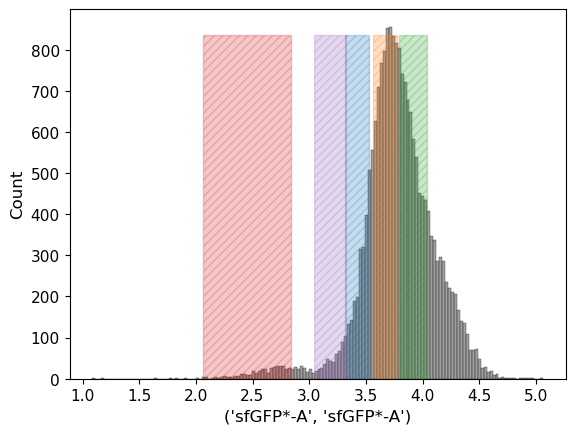

In [256]:
sns.histplot(np.log10(df_1[('sfGFP*-A', 'sfGFP*-A')]), color='grey')
color_num = 0

for bin_vals in sort_bins_1.keys():
    current_bin = sort_bins_1[bin_vals]
    plt.gca().add_patch(Rectangle((np.log10(current_bin[0]), 0), (np.log10(current_bin[1])-np.log10(current_bin[0])), 835, 
                                  color=cm.tab10.colors[color_num], hatch='////', alpha=0.25, clip_on=False))
    color_num += 1
    print(f'{current_bin[0]}, {current_bin[1]}')

fig_bins = plt.gcf()
fig_bins.savefig(f"Prelim_figures/Sort_bins_rep1.png", bbox_inches='tight')

Even prior to gating, the five fluorescence bins look good!

## Performing the three gating steps

In [259]:
# Defining a gating strategy
gate_strat = fk.GatingStrategy()

### Gate 1 (P1): Hexagonal gate on FSC-A and SSC-A

In [261]:
# Defining the two correponding dimensions
dim_fsc_a = fk.Dimension('FSC-A')
dim_ssc_a = fk.Dimension('SSC-A')

In [262]:
# Defining the corresponding polygonal gate
p1_vertices = gates_1['P1']['vertices']

hexa_gate = fk.gates.PolygonGate('hexa_p1', dimensions=[dim_fsc_a, dim_ssc_a], vertices=p1_vertices)

In [263]:
# Adding the gate to the gating strategy
gate_strat.add_gate(hexa_gate, gate_path=('root',))

In [264]:
# Attempting gating
res_1_P1 = gate_strat.gate_sample(sample_1)
res_1_P1.report

,sample,gate_path,gate_name,gate_type,quadrant_parent,parent,count,absolute_percent,relative_percent,level
0,fcy1_promDMS_sorting_rep1_20250128.fcs,"(root,)",hexa_p1,PolygonGate,None,root,19663,98.315,98.315,0


In [265]:
# Obtaining gate memberships
sample_1_P1_membership = res_1_P1.get_gate_membership('hexa_p1')

In [266]:
P1_samp1 = sample_1.plot_scatter('FSC-A', 'SSC-A', source='raw', subsample=False, highlight_mask=sample_1_P1_membership)
show(P1_samp1)

### Gate 2 (P2): Rectangular gate on SSC-H and SSC-W

In [268]:
# Defining the two correponding dimensions
dim_ssc_h = fk.Dimension('SSC-H')
dim_ssc_w = fk.Dimension('SSC-W')

In [269]:
# Defining the corresponding rectangular gate as a polygon
p2_vertices = gates_1['P2']['vertices']

rect1_gate = fk.gates.PolygonGate('rect_p2', dimensions=[dim_ssc_h, dim_ssc_w], vertices=p2_vertices)

In [270]:
# Adding the gate to the gating strategy
gate_strat.add_gate(rect1_gate, gate_path=('root', 'hexa_p1'))

In [271]:
# Attempting gating
res_1_P2 = gate_strat.gate_sample(sample_1)
res_1_P2.report

,sample,gate_path,gate_name,gate_type,quadrant_parent,parent,count,absolute_percent,relative_percent,level
0,fcy1_promDMS_sorting_rep1_20250128.fcs,"(root,)",hexa_p1,PolygonGate,None,root,19663,98.315,98.315000,0
1,fcy1_promDMS_sorting_rep1_20250128.fcs,"(root, hexa_p1)",rect_p2,PolygonGate,None,hexa_p1,4421,22.105,22.483853,1


In [272]:
# Obtaining gate memberships
sample_1_P2_membership = res_1_P2.get_gate_membership('rect_p2', gate_path=('root', 'hexa_p1'))

In [273]:
P2_samp1 = sample_1.plot_scatter('SSC-H', 'SSC-W', source='raw', subsample=False, highlight_mask=sample_1_P2_membership)
show(P2_samp1)

### Gate 3 (P3): Rectangular gate on FSC-H and FSC-W

In [275]:
# Defining the two correponding dimensions
dim_fsc_h = fk.Dimension('FSC-H')
dim_fsc_w = fk.Dimension('FSC-W')

In [276]:
# Defining the corresponding rectangular gate as a polygon
p3_vertices = gates_1['P3']['vertices']

rect2_gate = fk.gates.PolygonGate('rect_p3', dimensions=[dim_fsc_h, dim_fsc_w], vertices=p3_vertices)

In [277]:
# Adding the gate to the gating strategy
gate_strat.add_gate(rect2_gate, gate_path=('root', 'hexa_p1', 'rect_p2'))

In [278]:
# Attempting gating
res_1_P3 = gate_strat.gate_sample(sample_1)
res_1_P3.report

,sample,gate_path,gate_name,gate_type,quadrant_parent,parent,count,absolute_percent,relative_percent,level
0,fcy1_promDMS_sorting_rep1_20250128.fcs,"(root,)",hexa_p1,PolygonGate,None,root,19663,98.315,98.315000,0
1,fcy1_promDMS_sorting_rep1_20250128.fcs,"(root, hexa_p1)",rect_p2,PolygonGate,None,hexa_p1,4421,22.105,22.483853,1
2,fcy1_promDMS_sorting_rep1_20250128.fcs,"(root, hexa_p1, rect_p2)",rect_p3,PolygonGate,None,rect_p2,4383,21.915,99.140466,2


In [279]:
# Obtaining gate memberships
sample_1_P3_membership = res_1_P3.get_gate_membership('rect_p3', gate_path=('root', 'hexa_p1', 'rect_p2'))

In [280]:
P3_samp1 = sample_1.plot_scatter('FSC-H', 'FSC-W', source='raw', subsample=False, highlight_mask=sample_1_P3_membership)
show(P3_samp1)

### Same gating (only reports) for samples 2 and 3

In [282]:
res_2_P3 = gate_strat.gate_sample(sample_2)
res_2_P3.report

,sample,gate_path,gate_name,gate_type,quadrant_parent,parent,count,absolute_percent,relative_percent,level
0,fcy1_promDMS_sorting_rep2_20250129.fcs,"(root,)",hexa_p1,PolygonGate,None,root,19795,98.975,98.975000,0
1,fcy1_promDMS_sorting_rep2_20250129.fcs,"(root, hexa_p1)",rect_p2,PolygonGate,None,hexa_p1,5618,28.090,28.380904,1
2,fcy1_promDMS_sorting_rep2_20250129.fcs,"(root, hexa_p1, rect_p2)",rect_p3,PolygonGate,None,rect_p2,5585,27.925,99.412602,2


In [283]:
res_3_P3 = gate_strat.gate_sample(sample_3)
res_3_P3.report

,sample,gate_path,gate_name,gate_type,quadrant_parent,parent,count,absolute_percent,relative_percent,level
0,fcy1_promDMS_sorting_rep3_20250131.fcs,"(root,)",hexa_p1,PolygonGate,None,root,19831,99.155,99.155000,0
1,fcy1_promDMS_sorting_rep3_20250131.fcs,"(root, hexa_p1)",rect_p2,PolygonGate,None,hexa_p1,6797,33.985,34.274621,1
2,fcy1_promDMS_sorting_rep3_20250131.fcs,"(root, hexa_p1, rect_p2)",rect_p3,PolygonGate,None,rect_p2,6767,33.835,99.558629,2


### Since the fraction of events which pass the gates are so different, the same plots are also made

#### Sample 2

In [286]:
sample_2_P1_membership = res_2_P3.get_gate_membership('hexa_p1')

P1_samp2 = sample_2.plot_scatter('FSC-A', 'SSC-A', source='raw', subsample=False, highlight_mask=sample_2_P1_membership)
show(P1_samp2)

In [287]:
sample_2_P2_membership = res_2_P3.get_gate_membership('rect_p2')

P2_samp2 = sample_2.plot_scatter('SSC-H', 'SSC-W', source='raw', subsample=False, highlight_mask=sample_2_P2_membership)
show(P2_samp2)

In [288]:
sample_2_P3_membership = res_2_P3.get_gate_membership('rect_p3')

P3_samp2 = sample_2.plot_scatter('FSC-H', 'FSC-W', source='raw', subsample=False, highlight_mask=sample_2_P3_membership)
show(P3_samp2)

#### Sample 3

In [290]:
sample_3_P1_membership = res_3_P3.get_gate_membership('hexa_p1')

P1_samp3 = sample_3.plot_scatter('FSC-A', 'SSC-A', source='raw', subsample=False, highlight_mask=sample_3_P1_membership)
show(P1_samp3)

In [291]:
sample_3_P2_membership = res_3_P3.get_gate_membership('rect_p2')

P2_samp3 = sample_3.plot_scatter('SSC-H', 'SSC-W', source='raw', subsample=False, highlight_mask=sample_3_P2_membership)
show(P2_samp3)

In [292]:
sample_3_P3_membership = res_3_P3.get_gate_membership('rect_p3')

P3_samp3 = sample_3.plot_scatter('FSC-H', 'FSC-W', source='raw', subsample=False, highlight_mask=sample_3_P3_membership)
show(P3_samp3)

The shapes of the distributions remain overall consistent with what we have seen for replicate 1!

## Performing the sorting only on cells which pass the gating steps

In [295]:
# Adding the gate membership
df_1_gated = df_1.copy()
df_1_gated.columns = df_1_gated.columns.droplevel(1)
df_1_gated['Kept'] = sample_1_P3_membership
df_1_gated = df_1_gated[df_1_gated['Kept']].copy().reset_index(drop=True)

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


2091.0116239206377, 3398.1987171748783
3647.1553305311645, 5973.265614400292
6209.887318981933, 10973.78499702543
116.14564007554117, 692.3990240619734
1093.6867105032413, 2101.4995368500568


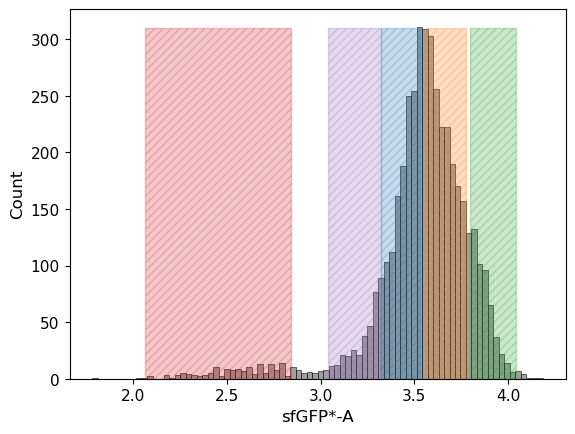

In [296]:
sns.histplot(np.log10(df_1_gated['sfGFP*-A']), color='grey')
color_num = 0

for bin_vals in sort_bins_1.keys():
    current_bin = sort_bins_1[bin_vals]
    bin_diff = np.log10(current_bin[1]) - np.log10(current_bin[0])
    plt.gca().add_patch(Rectangle((np.log10(current_bin[0]), 0), bin_diff, 310, 
                                  color=cm.tab10.colors[color_num], hatch='////', alpha=0.25, clip_on=False))
    color_num += 1
    print(f'{current_bin[0]}, {current_bin[1]}')

fig_bins = plt.gcf()
fig_bins.savefig(f"Prelim_figures/Sort_bins_gated_rep1.png", bbox_inches='tight')

This recovers almost exactly the picture from the preliminary experiment!

### Making sure that it is similar for replicates 2 and 3

#### Replicate 2

In [300]:
# Adding the gate membership
df_2_gated = df_2.copy()
df_2_gated.columns = df_2_gated.columns.droplevel(1)
df_2_gated['Kept'] = sample_2_P3_membership
df_2_gated = df_2_gated[df_2_gated['Kept']].copy().reset_index(drop=True)

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


2091.0116239206377, 3398.1987171748783
3647.1553305311645, 5973.265614400292
6209.887318981933, 10973.78499702543
116.14564007554117, 692.3990240619734
1093.6867105032413, 2101.4995368500568


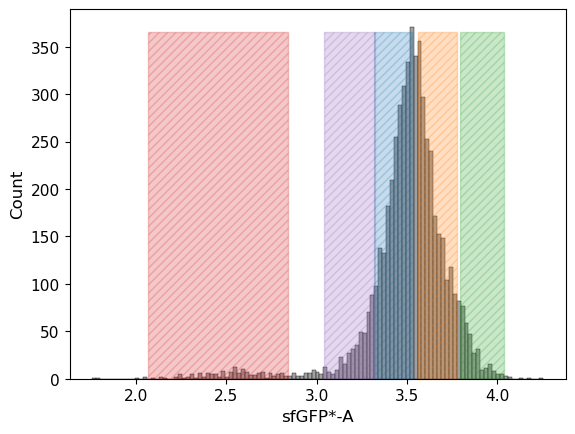

In [301]:
sns.histplot(np.log10(df_2_gated['sfGFP*-A']), color='grey')
color_num = 0

for bin_vals in sort_bins_2.keys():
    current_bin = sort_bins_2[bin_vals]
    bin_diff = np.log10(current_bin[1]) - np.log10(current_bin[0])
    plt.gca().add_patch(Rectangle((np.log10(current_bin[0]), 0), bin_diff, 365, 
                                  color=cm.tab10.colors[color_num], hatch='////', alpha=0.25, clip_on=False))
    color_num += 1
    print(f'{current_bin[0]}, {current_bin[1]}')

fig_bins = plt.gcf()
fig_bins.savefig(f"Prelim_figures/Sort_bins_gated_rep2.png", bbox_inches='tight')

#### Replicate 3

In [303]:
# Adding the gate membership
df_3_gated = df_3.copy()
df_3_gated.columns = df_3_gated.columns.droplevel(1)
df_3_gated['Kept'] = sample_3_P3_membership
df_3_gated = df_3_gated[df_3_gated['Kept']].copy().reset_index(drop=True)

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


2091.0116239206377, 3398.1987171748783
3647.1553305311645, 5973.265614400292
6209.887318981933, 10973.78499702543
116.14564007554117, 692.3990240619734
1093.6867105032413, 2101.4995368500568


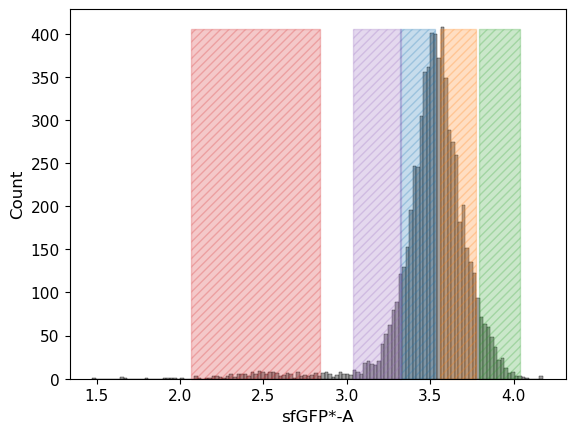

In [304]:
sns.histplot(np.log10(df_3_gated['sfGFP*-A']), color='grey')
color_num = 0

for bin_vals in sort_bins_3.keys():
    current_bin = sort_bins_3[bin_vals]
    bin_diff = np.log10(current_bin[1]) - np.log10(current_bin[0])
    plt.gca().add_patch(Rectangle((np.log10(current_bin[0]), 0), bin_diff, 405, 
                                  color=cm.tab10.colors[color_num], hatch='////', alpha=0.25, clip_on=False))
    color_num += 1
    print(f'{current_bin[0]}, {current_bin[1]}')

fig_bins = plt.gcf()
fig_bins.savefig(f"Prelim_figures/Sort_bins_gated_rep3.png", bbox_inches='tight')

# Second, for flow cytometry experiments

Here, we only need to generate scatterplots showing the FSC and SSC thresholds

## Importing data

The relevant code from Sort_calibration.ipynb and FCY1_fit_function_with_valid.ipynb has been copied.

### For validation mutants

In [310]:
# Importing the mapping of mutant_id to genotypes
mapping_df = pd.read_csv('Val_mutants_cytometry/genotypes_mapping.csv', index_col=None)
# Importing the plan of plate 1
plate1_df = pd.read_csv('Val_mutants_cytometry/plate_1.csv', index_col=None)

# Generating a dictionary of mutant_id -> Genotype mappings
id_to_gen = {mapping_df.at[row_num, 'mutant_id']: (mapping_df.at[row_num, 'Genotype'], mapping_df.at[row_num, 'T_insertion']) for row_num in range(mapping_df.shape[0])}

In [311]:
fluo_model = pd.DataFrame(columns=['Plate', 'Well', 'mutant_id', 'Genotype', 'T_insertion', 'replicate',
                                   "FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"])
fluo_df_valid = fluo_model.copy()

# Iteratively filling the dataframe with plate 1 data
plate1_path = "Val_mutants_cytometry/Cytometry_AKD_25-04-23/2025-04-23_at_01-25-01pm"

for row_num in range(plate1_df.shape[0]):
    well_id = plate1_df.at[row_num, 'Well']
    mutant_id = plate1_df.at[row_num, 'mutant_id']
    genotype = id_to_gen[mutant_id][0]
    t_insert = id_to_gen[mutant_id][1]
    rep_num = plate1_df.at[row_num, 'replicate']

    data_cyto = pd.read_csv(f'{plate1_path}/2025-04-23_at_01-25-01pm.{well_id}.csv')[["FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"]]

    data_cyto['Plate'] = 1
    data_cyto['Well'] = well_id
    data_cyto['mutant_id'] = mutant_id
    data_cyto['Genotype'] = genotype
    data_cyto['T_insertion'] = t_insert
    data_cyto['replicate'] = rep_num

    if row_num == 0:
        fluo_df_valid = data_cyto.copy()

    else:
        fluo_df_valid = pd.concat([fluo_df_valid, data_cyto]).reset_index(drop=True)

### For strains with promoters (fitness function measurements)

In [313]:
# df for 25-02
info_cyto_25 = pd.read_csv("FCY1_fit_func_data/df_plate_cytometry_25-02-17.csv")

# df for 24-09
info_cyto_24 = pd.read_csv("Fit_func_data_24-09/config_2C_24_09_04_SA.csv")[['well', 'Strain', 'Clone', 'Type']].copy()

In [314]:
# Dictionary for 25-02
dict_fluo_25 = {}

for row in range(info_cyto_25.shape[0]):
    well = info_cyto_25.at[row, 'Well']
    strain = info_cyto_25.at[row, 'Strain']
    clone = info_cyto_25.at[row, 'Clone']
    strain_label = info_cyto_25.at[row, 'Label']
    if strain_label == 'FCY1 deletion':
        strain_label = 'Blank'
    
    dict_fluo_25[well] = [strain, clone, strain_label]

# Dictionary for 24-09
dict_fluo_24 = {}

to_label_dict = {'AKD1123': 'Blank', '42bp-mEGFP': 'Wild-type'}

for row in range(info_cyto_24.shape[0]):
    well = info_cyto_24.at[row, 'well']
    strain = info_cyto_24.at[row, 'Strain']
    clone = info_cyto_24.at[row, 'Clone']
    strain_label = info_cyto_24.at[row, 'Type']

    if strain not in ['AKD1123', '42bp-mEGFP']:
        strain = 'p'+ strain
        strain_label = strain
    
    dict_fluo_24[well] = [strain, clone, strain_label]

In [315]:
# First generating the dataframe for the 25-02 data

# Looping over the wells for which we have data
n_iter = 0
for well_num in dict_fluo_25.keys():

    # Try loading the data, if the well has been measured at the cytometer
    file_path = f"FCY1_fit_func_data/2025-02-18_at_04-04-31pm/2025-02-18_at_04-04-31pm.{well_num}.csv"
    try:
        data_all = pd.read_csv(file_path)
    except:
        continue

    # Obtain the data and concatenate in the larger dataframe
    current_df = pd.DataFrame(columns = ['Well', 'Strain', 'Label', 'Clone', "FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"])
    
    strain = dict_fluo_25[well_num][0]
    clone = dict_fluo_25[well_num][1]
    strain_label = dict_fluo_25[well_num][2]
    
    current_df[["FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"]] = data_all[["FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"]].copy()

    current_df['Well'] = well_num
    current_df['Strain'] = strain
    current_df['Label'] = strain_label
    current_df['Clone'] = clone

    if n_iter == 0:
        data_fluo_25 = current_df.copy()

    else:
        data_fluo_25 = pd.concat([data_fluo_25, current_df]).reset_index(drop=True)

    n_iter += 1

In [316]:
# Second, for the 24-09 data
n_iter = 0

for well_num in dict_fluo_24.keys():

    # Try loading the data, if the well has been measured at the cytometer
    file_path = f"Fit_func_data_24-09/2024-09-04_at_06-48-44pm_plate2C/2024-09-04_at_06-48-44pm_plate2C.{well_num}.csv"
    try:
        data_all = pd.read_csv(file_path)
    except:
        continue

    # Obtain the data and concatenate in the larger dataframe
    current_df = pd.DataFrame(columns = ['Well', 'Strain', 'Label', 'Clone', "FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"])
    
    strain = dict_fluo_24[well_num][0]
    clone = dict_fluo_24[well_num][1]
    strain_label = dict_fluo_24[well_num][2]
    
    current_df[["FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"]] = data_all[["FSC-HLin", "SSC-HLin", "GRN-B-HLin", "YEL-B-HLin"]].copy()

    current_df['Well'] = well_num
    current_df['Strain'] = strain
    current_df['Label'] = strain_label
    current_df['Clone'] = clone

    if n_iter == 0:
        data_fluo_24 = current_df.copy()

    else:
        data_fluo_24 = pd.concat([data_fluo_24, current_df]).reset_index(drop=True)

    n_iter += 1

## Establishing the FSC and SSC thersholds

As previously performed in the corresponding notebooks.

In [319]:
# For validation mutants
fsc_valid = np.percentile(fluo_df_valid['FSC-HLin'], 99)
ssc_valid = np.percentile(fluo_df_valid['SSC-HLin'], 99)

In [320]:
# For the strains with inserted promoters
fsc_max = np.percentile(pd.concat([data_fluo_24['FSC-HLin'], data_fluo_25['FSC-HLin']]), 99)
ssc_max = np.percentile(pd.concat([data_fluo_24['SSC-HLin'], data_fluo_25['SSC-HLin']]), 99)

## Constructing the figure

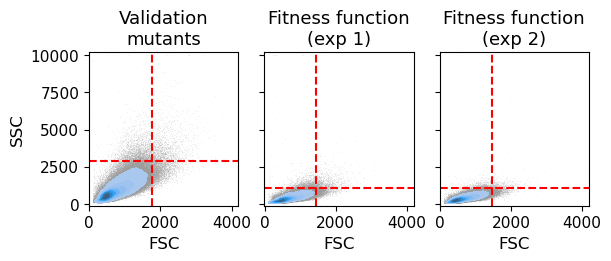

In [406]:
plt.rcParams['savefig.dpi'] = 600
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 11

fig, axs = plt.subplots(1, 3, figsize=(6, 2.5), constrained_layout=True, sharex=True, sharey=True)

sns.kdeplot(x='FSC-HLin', y='SSC-HLin', data=fluo_df_valid, ax=axs[0], fill=True, zorder=1)
sns.scatterplot(x='FSC-HLin', y='SSC-HLin', data=fluo_df_valid, ax=axs[0], zorder=0, color='grey', s=0.1, alpha=0.75)
axs[0].axhline(y=ssc_valid, c='red', linestyle='--', zorder=2)
axs[0].axvline(x=fsc_valid, c='red', linestyle='--', zorder=2)

sns.kdeplot(x='FSC-HLin', y='SSC-HLin', data=data_fluo_24, ax=axs[1], fill=True, zorder=1)
sns.scatterplot(x='FSC-HLin', y='SSC-HLin', data=data_fluo_24, ax=axs[1], zorder=0, color='grey', s=0.1, alpha=0.75)
axs[1].axhline(y=ssc_max, c='red', linestyle='--', zorder=2)
axs[1].axvline(x=fsc_max, c='red', linestyle='--', zorder=2)

sns.kdeplot(x='FSC-HLin', y='SSC-HLin', data=data_fluo_25, ax=axs[2], fill=True, zorder=1)
sns.scatterplot(x='FSC-HLin', y='SSC-HLin', data=data_fluo_25, ax=axs[2], zorder=0, color='grey', s=0.1, alpha=0.75)
axs[2].axhline(y=ssc_max, c='red', linestyle='--', zorder=2)
axs[2].axvline(x=fsc_max, c='red', linestyle='--', zorder=2)

axs[0].set_ylabel('SSC')
axs[0].set_xlabel('FSC')
axs[1].set_xlabel('FSC')
axs[2].set_xlabel('FSC')

axs[0].set_title('Validation\nmutants', fontsize=13)
axs[1].set_title('Fitness function\n(exp 1)', fontsize=13)
axs[2].set_title('Fitness function\n(exp 2)', fontsize=13)

fig_cyto = plt.gcf()
fig_cyto.savefig(f"Supp_figs/Fig_supp_cyto.tiff", bbox_inches='tight')